In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.model_selection import train_test_split
from statsmodels.stats.anova import anova_lm

In [43]:
data = pd.read_csv(r"C:\Users\No\Documents\R\data\processed\therapy_recovery_clean.csv").drop(columns=['patient_id', 'admit_date', 'discharge_date', 'discharge_date_fix'])

data.head()

,therapy,sex,age_years,age_band,comorbidity,los_final_days
0,std,F,49,40-64 歲,mild,13
1,std,F,60,40-64 歲,none,11
2,new,F,76,65 歲以上,mild,8
3,new,M,53,40-64 歲,mild,12
4,std,F,18,<40 歲,severe,15


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   therapy         200 non-null    object
 1   sex             200 non-null    object
 2   age_years       200 non-null    int64 
 3   age_band        200 non-null    object
 4   comorbidity     200 non-null    object
 5   los_final_days  200 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 9.5+ KB


<BarContainer object of 2 artists>

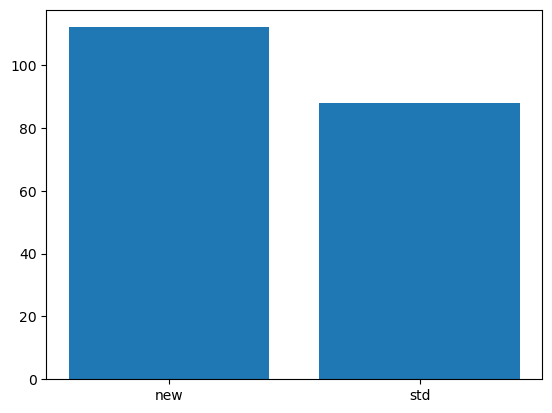

In [45]:
plt.bar(x=data['therapy'].value_counts().index, height=data['therapy'].value_counts().values)


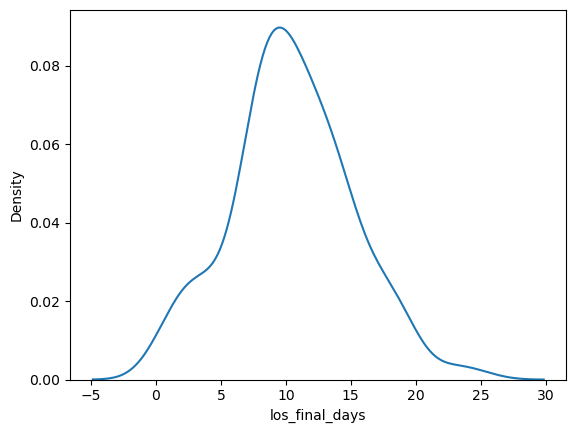

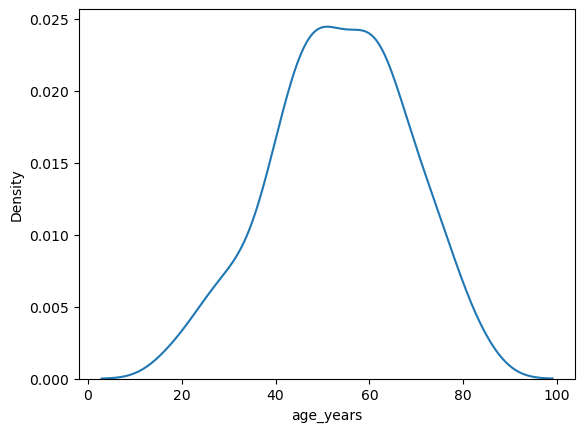

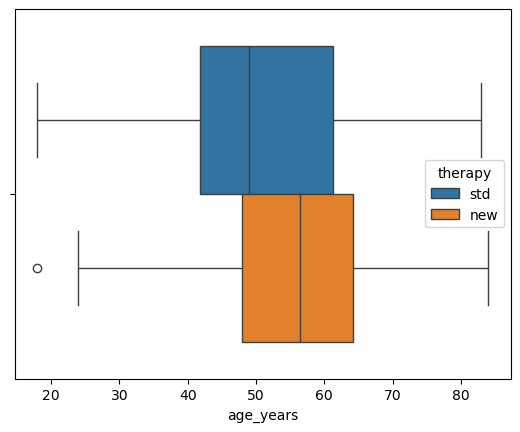

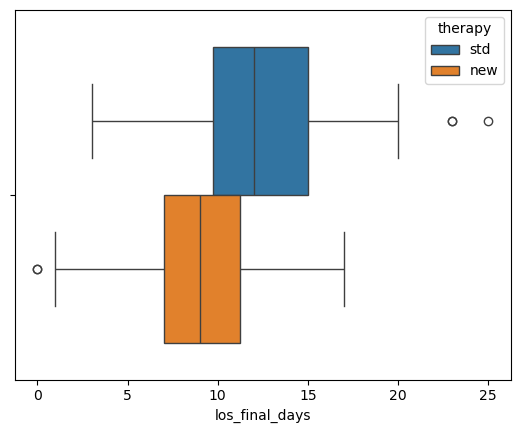

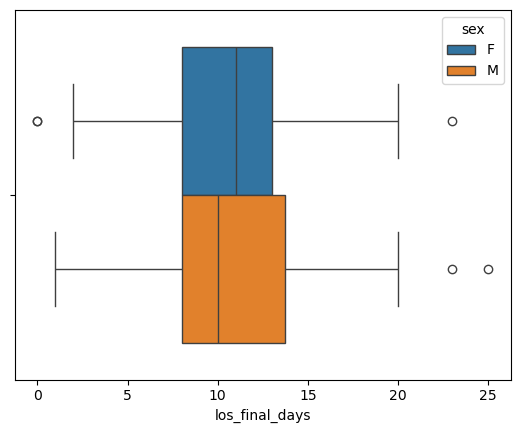

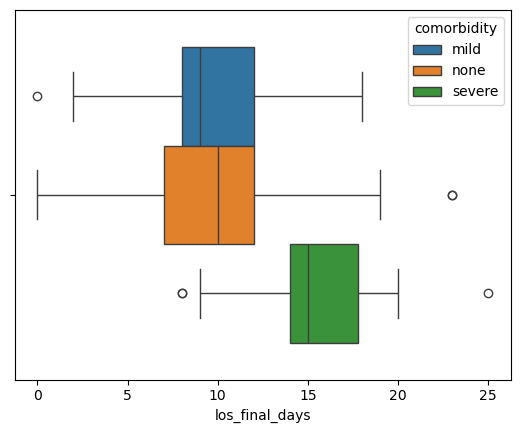

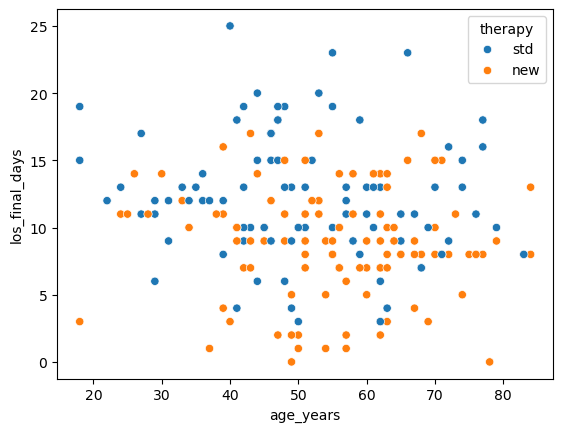

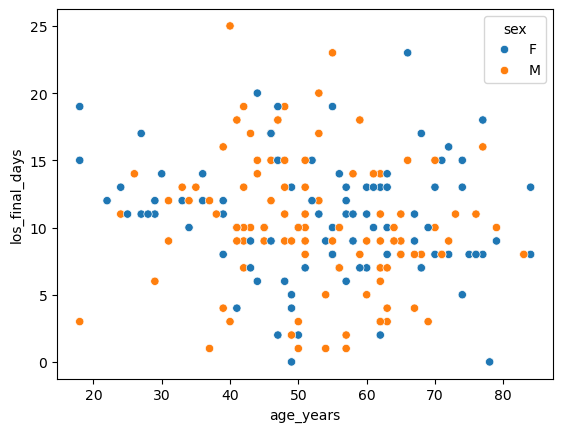

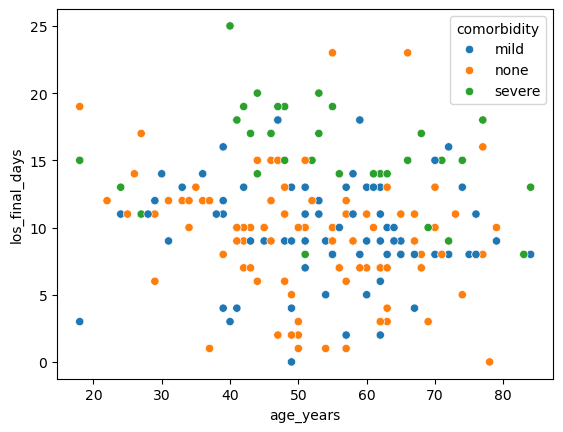

In [46]:
sns.kdeplot(data=data, x='los_final_days')
plt.show()
sns.kdeplot(data=data, x='age_years')
plt.show()
sns.boxplot(data=data, x='age_years', hue='therapy')
plt.show()

sns.boxplot(data=data, x='los_final_days', hue='therapy')
plt.show()

sns.boxplot(data=data, x='los_final_days', hue='sex')
plt.show()

sns.boxplot(data=data, x='los_final_days', hue='comorbidity')
plt.show()

sns.scatterplot(data=data, x='age_years', y='los_final_days', hue='therapy')
plt.show()

sns.scatterplot(data=data, x='age_years', y='los_final_days', hue='sex')
plt.show()

sns.scatterplot(data=data, x='age_years', y='los_final_days', hue='comorbidity')
plt.show()

C:\Users\No\AppData\Local\Temp\ipykernel_27868\1611781973.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=order, showmeans=True)


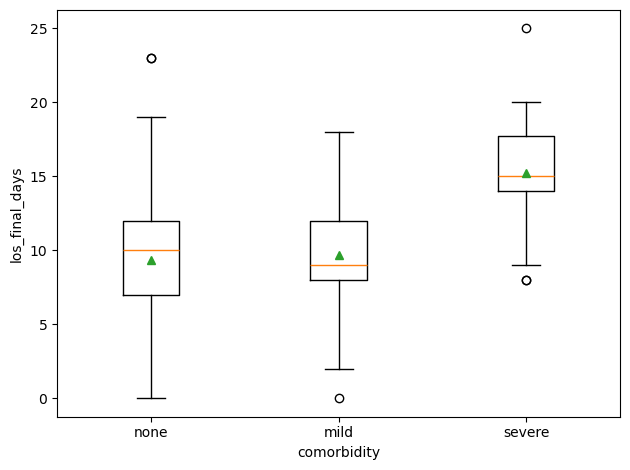

In [47]:
plt.figure()
order = ['none','mild','severe'] if set(['none','mild','severe']).issubset(set(data['comorbidity'].unique())) else sorted(data['comorbidity'].unique())
groups = [data.loc[data['comorbidity']==g, 'los_final_days'].values for g in order]
plt.boxplot(groups, labels=order, showmeans=True)
plt.xlabel("comorbidity")
plt.ylabel("los_final_days")
plt.tight_layout()
plt.show()

In [40]:
# 變異數檢定
# lev_stat, lev_p = stats.levene(*groups, center='median')
# print(f"\nLevene test: stat={lev_stat:.4f}, p={lev_p:.4f}")

# 單因子 ANOVA
model = smf.ols("los_final_days ~ C(comorbidity)", data=data).fit()
anova_tbl = anova_lm(model, typ=2)
print("\n=== One-way ANOVA ===")
print(anova_tbl)

SS_between = anova_tbl.loc['C(comorbidity)', 'sum_sq']
SS_resid   = anova_tbl.loc['Residual', 'sum_sq']
eta_sq = SS_between / (SS_between + SS_resid)
print(f"eta^2 = {eta_sq:.3f}")


=== One-way ANOVA ===
                     sum_sq     df          F        PR(>F)
C(comorbidity)   937.926861    2.0  27.062228  4.129104e-11
Residual        3413.828139  197.0        NaN           NaN
eta^2 = 0.216


In [31]:
formula = "los_final_days ~ C(sex, Treatment('M'))+C(therapy, Treatment('std'))+C(comorbidity, Treatment('none'))"
ols = smf.ols(formula=formula, data=data).fit(cov_type='nonrobust')
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:         los_final_days   R-squared:                       0.334
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     24.42
Date:                Tue, 07 Oct 2025   Prob (F-statistic):           2.14e-16
Time:                        12:03:40   Log-Likelihood:                -551.18
No. Observations:                 200   AIC:                             1112.
Df Residuals:                     195   BIC:                             1129.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------